In [1]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

%matplotlib inline

pd.options.mode.chained_assignment = None

In [2]:
class QAOA():
    """
    Implements QAOA for portfolio optimization using a quantum circuit to solve QUBO problems.
    
    Attributes:
        expected_value (list[float]): Expected returns for each asset.
        cov_matrix (DataFrame-like): Covariance matrix between assets.
        q (float): Scaling factor for covariance.
        B (float): Budget/threshold parameter.
        lamb (float): Penalty factor.
        n_assets (int): Number of assets/qubits.
        qc (QuantumCircuit): Initialized circuit in equal superposition.
    """
    
    def __init__(self, expected_value, cov_matrix, q, B, lamb):
        """
        Initializes the QAOA instance and prepares the quantum circuit.
        
        Args:
            expected_value (list[float]): List of asset returns.
            cov_matrix (DataFrame-like): Covariance matrix.
            q (float): Covariance scaling factor.
            B (float): Budget/threshold parameter.
            lamb (float): Penalty parameter.
        """
        
        self.q = q
        self.B = B
        self.lamb = lamb
        self.expected_value = expected_value
        self.cov_matrix = cov_matrix
        self.n_assets = len(expected_value)
        
        self.qc = QuantumCircuit(self.n_assets, self.n_assets)
        # Initialization - prepare an equal superposition state
        for qubit in range(self.n_assets):
            self.qc.h(qubit)
        self.qc.barrier()
        
    
    def cost_hamiltonian_wheight(self, i, j=None):
        """
        Calculate the weights for the Hamiltonian of the QUBO problem.
        
        Args:
            i (int): Index of the first asset.
            j (int, optional): Index of the second asset. Defaults to None.
            
        Returns:
            float: The weight that multiplies the product of the Z operators, acting on qubits i and j.
        """
        
        if j is None:
            response =2*self.expected_value[i]+2*self.lamb*(2*self.B-self.n_assets)-self.q*self.cov_matrix[i].drop([i], axis=0).sum()
        else:
            response = q*self.cov_matrix[i][j]+2*self.lamb
        return response
    
    def draw(self):
        """
        Draws the quantum circuit using matplotlib.
        """
        self.qc.draw(output="mpl", style="iqp")
    
    def add_layer(self, gamma, beta):
        """
        Adds one QAOA layer to the circuit.
        
        This layer applies:
            - Cost Hamiltonian: exp(-i*gamma*H_c) using CNOT and RZ gates.
            - Mixing Hamiltonian: exp(-i*beta*H_B) using RX gates.
        
        Args:
            gamma (float): Parameter for the cost Hamiltonian.
            beta (float): Parameter for the mixing Hamiltonian.
        """
        
        # Implement exp(-i*gamma*H_c)
        # H_c: Cost Hamiltonian
        for i in range(self.n_assets):
            for j in range(i+1, self.n_assets):
                self.qc.cx(i, j)
                self.qc.rz(2*gamma*self.cost_hamiltonian_wheight(i, j), j)
                self.qc.cx(i, j)
        for qubit in range(self.n_assets):
            self.qc.rz(2*gamma*self.cost_hamiltonian_wheight(qubit), qubit)
        self.qc.barrier()
                
        # Implement exp(-i*beta*H_B)
        # H_B = sum(X_i): Mixture Hamiltonian
        for qubit in range(self.n_assets):
             self.qc.rx(2*beta, qubit)
        self.qc.barrier()
             
    def measure_energy(self):
        """
        Measures the circuit and computes the expected energy.
        
        Returns:
            tuple: (energy, counts) where energy is the expected value and counts is the measurement distribution.
    
        """
        
        self.qc.measure(range(self.n_assets), range(self.n_assets))

        simulator = AerSimulator()
        compiled_circuit = transpile(self.qc, simulator)
        sim_result = simulator.run(self.qc).result()
        counts = sim_result.get_counts()
        
        energy = 0
        total_shots = sum(counts.values())
        for bitstring, count in counts.items():
            prob = count / total_shots
            
            Z = [1 if bitstring[::-1][i] == '0' else -1 for i in range(self.n_assets)]
            
            energy_outcome = 0
            for i in range(self.n_assets):
                energy_outcome += self.cost_hamiltonian_wheight(i)*Z[i]
                for j in range(i+1, self.n_assets):
                    energy_outcome += self.cost_hamiltonian_wheight(i, j)*Z[i]*Z[j]
            
            energy += prob * energy_outcome
    
        return energy, counts
        

In [3]:
# Derived key metrics for assets (BRKM5.SA, ITUB4.SA, VALE3.SA, KLBN4.SA) over the period from 2016-01-01 to 2021-09-20
expected_value = [0.335649, 0.084554, 0.357477, 0.148336]
cov_matrix = 252*pd.DataFrame([
 [0.001077, 0.000257,0.000320,0.000190],
 [0.000257,	0.000441,0.000228,0.000084],
 [0.000320,	0.000228, 0.000867,0.000154],
 [0.000190,	0.000084,0.000154,0.000420]
])

q = 0.5 
B  = 2 
lamb= 1

## Neural Networking model

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

In [5]:
class NN_QAOA(nn.Module):
    
    def __init__(self, depth=10, vocab_size=5, latent_dim=5):
        super(NN_QAOA, self).__init__()
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 2*depth*vocab_size),
            nn.ReLU(),
            nn.Linear(2*depth*vocab_size, 2*depth*vocab_size)
        )
        
        self.latent_dim = latent_dim
        self.vocab_size = vocab_size
        self.depth = depth
        
        self.gamma = [
                      [(i/(vocab_size-1))*2*np.pi for i in range(vocab_size)]
                      for _ in range(depth)
                     ]
        self.beta = [
                     [(i/(vocab_size-1))*np.pi for i in range(vocab_size)]
                     for _ in range(depth)
                    ]

    def forward(self, z, beta_temp=5):
        x = nn_qaoa.decoder(z)
        W = x.view(-1, nn_qaoa.vocab_size)
        probabilities = torch.softmax(-beta_temp*W, dim=-1)
        sample_index = torch.multinomial(probabilities, num_samples=1)
        w = W[torch.arange(W.size(0)), sample_index.view(sample_index.size(0))].view(x.size(0), -1)
        sampled_index = sample_index.view(x.size(0), -1)
        
        energy = []
        for i in range(sampled_index.size(0)):
            sampled_index_i = sampled_index[i]
            gamma_array = []
            sampled_index_gamma = sampled_index_i[:self.depth]
            sampled_index_beta = sampled_index_i[self.depth:]
            for j in range(len(sampled_index_gamma)):
                gamma_array.append(self.gamma[j][sampled_index_gamma[j]])
            beta_array = []
            for j in range(len(sampled_index_beta)):
                beta_array.append(self.beta[j][sampled_index_beta[j]])
                
            qaoa = QAOA(expected_value, cov_matrix, q, B, lamb)
            for j in range(depth):
                qaoa.add_layer(gamma_array[j], beta_array[j])
            energy_i, count = qaoa.measure_energy()
            
            energy.append(energy_i)
        energy = torch.tensor(np.array(energy))
        
        return w, energy, count, gamma_array, beta_array
    
def f_loss(w, energies):
    
    response = torch.mean((torch.exp(-torch.sum(w, dim=1))-torch.exp(-energies)).pow(2))
    return response

In [6]:
def epoch_train(model, optimizer, batch_size, beta_temp=5):
    data = []
    z = torch.ones(size=(batch_size, 1, latent_dim))
    w, energies, count, gamma, beta = model(z, beta_temp=beta_temp)
    df = pd.DataFrame(energies, columns=['energy'])
    
    optimizer.zero_grad()
    loss = f_loss(w, energies)
    loss.backward()
    optimizer.step()
        
    return df, loss.item()

In [7]:
latent_dim = 5
vocab_size = 5
batch_size = 15
epochs = 30
beta_temp = 1
depth = 2

In [8]:
nn_qaoa = NN_QAOA(depth=depth, vocab_size=vocab_size, latent_dim=latent_dim)
optimizer = optim.Adam(nn_qaoa.parameters(), lr=0.01)

## Model Training

In [9]:
df = pd.DataFrame()
for i in range(1, epochs+1):
    df_i, loss_i = epoch_train(nn_qaoa, optimizer, batch_size, beta_temp=beta_temp)
    df_i['loss'] = loss_i
    df_i['epoch'] = i
    df = pd.concat([df, df_i])
    print(f"Epoch {i}, Loss: {loss_i:.2f}, Energy mean: {df_i['energy'].mean():.2f}")

Epoch 1, Loss: 2.39, Energy mean: 0.42
Epoch 2, Loss: 8.32, Energy mean: 1.05
Epoch 3, Loss: 2.35, Energy mean: -0.28
Epoch 4, Loss: 3.58, Energy mean: 0.86
Epoch 5, Loss: 3.99, Energy mean: 1.61
Epoch 6, Loss: 7.82, Energy mean: 0.87
Epoch 7, Loss: 3.84, Energy mean: 0.52
Epoch 8, Loss: 2.01, Energy mean: 0.44
Epoch 9, Loss: 16.77, Energy mean: -0.41
Epoch 10, Loss: 8.24, Energy mean: -0.22
Epoch 11, Loss: 3.83, Energy mean: 0.20
Epoch 12, Loss: 10.23, Energy mean: 0.14
Epoch 13, Loss: 2.59, Energy mean: -0.33
Epoch 14, Loss: 8.28, Energy mean: 0.50
Epoch 15, Loss: 5.94, Energy mean: 2.05
Epoch 16, Loss: 11.36, Energy mean: -0.39
Epoch 17, Loss: 14.28, Energy mean: -0.62
Epoch 18, Loss: 4.18, Energy mean: 1.53
Epoch 19, Loss: 4.36, Energy mean: -0.10
Epoch 20, Loss: 6.80, Energy mean: 0.20
Epoch 21, Loss: 6.46, Energy mean: 0.69
Epoch 22, Loss: 8.87, Energy mean: 0.14
Epoch 23, Loss: 8.65, Energy mean: 0.16
Epoch 24, Loss: 2.56, Energy mean: 0.18
Epoch 25, Loss: 1.57, Energy mean: 0.2

## Inference

In [10]:
z = torch.ones(size=(1, latent_dim))
w, energy, count, gamma, beta = nn_qaoa(z, beta_temp=100000)
energy

tensor([-1.3642], dtype=torch.float64)

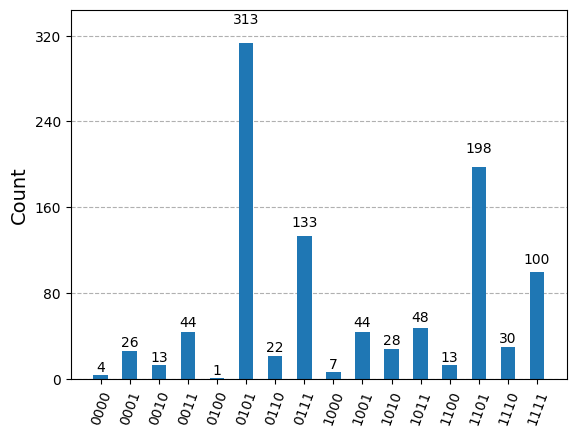

In [11]:
plot_histogram(count)
plt.show()

In [12]:
gamma

[3.141592653589793, 1.5707963267948966]

In [13]:
beta

[0.7853981633974483, 0.7853981633974483]